In [ ]:
 !git clone -b Exam_Project https://github.com/filipani/Data_Processing_And_Analysis_UniCourse.git

Cloning into 'Data_Processing_And_Analysis_UniCourse'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 42 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 1.12 MiB | 7.39 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [1]:
#loading the data
import pandas as pd


columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Prova questo percorso esatto
df = pd.read_csv('/content/Data_Processing_And_Analysis_UniCourse/agaricus-lepiota.data', names=columns)

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Data_Processing_And_Analysis_UniCourse/agaricus-lepiota.data'

In [2]:
#loading the data usando vscode
import pandas as pd


columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Prova questo percorso esatto
df = pd.read_csv('agaricus-lepiota.data', names=columns)

print(df.shape)
df.head()
!ls Data_Processing_And_Analysis_UniCourse/agaricus-lepiota.data

(8124, 23)


"ls" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [3]:
# exploratory data analysis

print('=== dtypes ===')
print(df.dtypes)
print('\n=== missing values ===')
print(df.isnull().sum())
print('\n=== value counts for stalk-root ===')
print(df['stalk-root'].value_counts())
print('\n=== describe (numeric) ===')
print(df.describe())

=== dtypes ===
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

=== missing values ===
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
g

In [ ]:
#df_reduced = df.drop(columns=['stalk-root'])

In [4]:

unique_counts = df.nunique()

print("Conteggio valori unici per colonna:")
print(unique_counts)


cols_to_drop = unique_counts[unique_counts == 1].index.tolist()

print(f"\n--- Colonne da rimuovere (Varianza Zero): {cols_to_drop} ---")

Conteggio valori unici per colonna:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

--- Colonne da rimuovere (Varianza Zero): ['veil-type'] ---


In [5]:
# Rimuoviamo le colonne con varianza zero

def check_nzv(data, threshold=0.95):
    nzv_report = []
    for col in data.columns:
        # Calcoliamo la frequenza del valore più comune
        most_freq_ratio = data[col].value_counts(normalize=True).iloc[0]
        # Numero di valori unici
        unique_values = data[col].nunique()

        nzv_report.append({
            'Colonna': col,
            'Frequenza Valore Dominante': f"{most_freq_ratio:.2%}",
            'Valori Unici': unique_values,
            'Is_NZV': most_freq_ratio > threshold
        })

    return pd.DataFrame(nzv_report)

# Eseguiamo l'analisi sul dataset pulito precedentemente
report = check_nzv(df)
print(report.sort_values(by='Frequenza Valore Dominante', ascending=False))

                     Colonna Frequenza Valore Dominante  Valori Unici  Is_NZV
17                veil-color                     97.54%             4    True
6            gill-attachment                     97.42%             2    True
18               ring-number                     92.17%             3   False
7               gill-spacing                     83.85%             2   False
8                  gill-size                     69.08%             2   False
12  stalk-surface-above-ring                     63.71%             4   False
13  stalk-surface-below-ring                     60.76%             4   False
4                    bruises                     58.44%             2   False
10               stalk-shape                     56.72%             2   False
14    stalk-color-above-ring                     54.95%             9   False
15    stalk-color-below-ring                     53.96%             9   False
0                      class                     51.80%         

In [6]:
#varianza controllata con gini normalizzato

def gini_normalized(df):
    gini_dict = {}

    for col in df.columns:
        probs = df[col].value_counts(normalize=True, dropna=True)

        gini = 1 - (probs**2).sum()

        k = len(probs)

        if k > 1:
            gini_max = 1 - 1/k
            gini_norm = gini / gini_max
        else:
            gini_norm = 0

        gini_dict[col] = gini_norm

    return pd.Series(gini_dict).sort_values(ascending=False)


gini_scores = gini_normalized(df)
print(gini_scores)

class                       0.998708
stalk-shape                 0.981932
bruises                     0.971479
gill-color                  0.937415
cap-color                   0.889990
cap-surface                 0.880014
habitat                     0.870007
spore-print-color           0.856399
gill-size                   0.854393
stalk-root                  0.833159
odor                        0.814776
population                  0.813940
ring-type                   0.773965
cap-shape                   0.760135
stalk-surface-below-ring    0.724981
stalk-color-below-ring      0.723536
stalk-color-above-ring      0.712526
stalk-surface-above-ring    0.672264
gill-spacing                0.541662
ring-number                 0.217455
gill-attachment             0.100725
veil-color                  0.064467
veil-type                   0.000000
dtype: float64


In [7]:

cols_to_remove = ['veil-type', 'veil-color', 'gill-attachment', 'stalk-root']


df_final = df.drop(columns=cols_to_remove)

print(f"Rimosse {len(cols_to_remove)} colonne.")
print(f"Dataset attuale: {df_final.shape[1]} colonne rimaste.")
print("\nPrime 5 righe del dataset pulito:")
df_final.head()

Rimosse 4 colonne.
Dataset attuale: 19 colonne rimaste.

Prime 5 righe del dataset pulito:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-spacing,gill-size,gill-color,stalk-shape,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,c,n,k,e,s,s,w,w,o,p,k,s,u
1,e,x,s,y,t,a,c,b,k,e,s,s,w,w,o,p,n,n,g
2,e,b,s,w,t,l,c,b,n,e,s,s,w,w,o,p,n,n,m
3,p,x,y,w,t,p,c,n,n,e,s,s,w,w,o,p,k,s,u
4,e,x,s,g,f,n,w,b,k,t,s,s,w,w,o,e,n,a,g


In [ ]:
#per ora skippare


from sklearn.preprocessing import LabelEncoder

df_labeled = df_f
inal.copy()


label_encoders = {}

for col in df_labeled.columns:

    le = LabelEncoder()
    df_labeled[col] = le.fit_transform(df_labeled[col])
    label_encoders[col] = le


print("--- DATASET FATTORIZZATO ---")
display(df_labeled.head())


print("\n" + "="*40)
print("LEGENDE DELLE VARIABILI (Mapping)")
print("="*40)

for col, le in label_encoders.items():

    mapping = dict(zip(le.transform(le.classes_), le.classes_))


    print(f"\n[ {col.upper()} ]")

    for num in sorted(mapping.keys()):
        print(f"  {num} : {mapping[num]}")

print("\n" + "="*40)
print("FINE REPORT")

NameError: name 'df_f' is not defined

In [8]:
#Versione senza eliminare stalk root (missing potrebbero avere un significato) e con dummy

from sklearn.preprocessing import OneHotEncoder


cols_to_remove2 = ['veil-type', 'veil-color', 'gill-attachment']


df_final2 = df.drop(columns=cols_to_remove2)

print(f"Rimosse {len(cols_to_remove2)} colonne.")
print(f"Dataset attuale: {df_final2.shape[1]} colonne rimaste.")
#print(df_final2.head())

columns = list(df_final2.columns)

encoder = OneHotEncoder(drop='first', sparse_output=False, dtype='int')
encoded_data = encoder.fit_transform(df_final2[columns])
encoded_cols = encoder.get_feature_names_out(columns)
df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols, index=df_final2.index)

print("--- DATASET CON DUMMY VARIABLES ---")
print(f"Forma finale del dataset: {df_encoded.shape}")
print(df_encoded.head())

Rimosse 3 colonne.
Dataset attuale: 20 colonne rimaste.
--- DATASET CON DUMMY VARIABLES ---
Forma finale del dataset: (8124, 92)
   class_p  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        1            0            0            0            0            1   
1        0            0            0            0            0            1   
2        0            0            0            0            0            0   
3        1            0            0            0            0            1   
4        0            0            0            0            0            1   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  ...  \
0              0              1              0            0  ...   
1              0              1              0            0  ...   
2              0              1              0            0  ...   
3              0              0              1            0  ...   
4              0              1              0          

In [9]:
#train-validation split

from sklearn.model_selection import train_test_split

X = df_encoded.drop('class_p', axis=1)
y = df_encoded['class_p']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5686, 91), (2438, 91), (5686,), (2438,))

In [21]:
#random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [500],
    'max_depth': [None, 10, 20],
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

#valutazione sul test set
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

precision_edible = precision_score(y_test, y_pred, pos_label=0)
print("Precision (edible, cioè sicurezza nel mangiabile):", precision_edible)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

Precision (edible, cioè sicurezza nel mangiabile): 1.0


In [22]:
#feature importance

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

X_sel=df_encoded.loc[:, importances[:25].index]
X_sel_train, X_sel_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.3, random_state=42, stratify=y
)

X_sel_train.shape, X_sel_test.shape, y_train.shape, y_test.shape


#a fini interpretativi

def get_original_feature(col_name):
    return col_name.split('_')[0]

df_imp = pd.DataFrame({
    'feature': importances.index,
    'importance': importances.values
})

df_imp['original'] = df_imp['feature'].apply(get_original_feature)

agg_importance = df_imp.groupby('original')['importance'].sum().sort_values(ascending=False)

print("\nAggregated feature importance:")
print(agg_importance)

odor_n                        0.159368
gill-size_n                   0.087016
odor_f                        0.083674
stalk-surface-above-ring_k    0.045532
ring-type_p                   0.044539
                                ...   
cap-color_u                   0.000176
gill-color_o                  0.000164
cap-shape_c                   0.000139
spore-print-color_o           0.000044
spore-print-color_y           0.000021
Length: 91, dtype: float64

Aggregated feature importance:
original
odor                        0.299440
spore-print-color           0.106120
gill-size                   0.087016
stalk-surface-above-ring    0.067715
ring-type                   0.062395
stalk-surface-below-ring    0.059541
population                  0.055148
stalk-root                  0.051784
bruises                     0.041979
habitat                     0.031333
gill-spacing                0.024560
cap-color                   0.019728
ring-number                 0.017925
stalk-shape           

In [23]:

# Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score


dt = DecisionTreeClassifier(random_state=42)


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


grid.fit(X_train, y_train)


best_model = grid.best_estimator_


y_pred = best_model.predict(X_test)


print("--- DECISION TREE RESULTS ---")
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


precision_edible = precision_score(y_test, y_pred, pos_label=0)
print("Precision (edible, cioè sicurezza nel mangiabile):", precision_edible)


--- DECISION TREE RESULTS ---
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

Precision (edible, cioè sicurezza nel mangiabile): 1.0


In [24]:
#regressione logistica



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score


log_reg = LogisticRegression(random_state=42, max_iter=1000)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}


grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


grid.fit(X_train, y_train)


best_model = grid.best_estimator_


y_pred = best_model.predict(X_test)


print("--- GLM (LOGISTIC REGRESSION) RESULTS ---")
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


precision_edible = precision_score(y_test, y_pred, pos_label=0)
print("Precision (edible, cioè sicurezza nel mangiabile):", precision_edible)

--- GLM (LOGISTIC REGRESSION) RESULTS ---
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

Precision (edible, cioè sicurezza nel mangiabile): 1.0


In [ ]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score, make_scorer

param_grid = {'n_neighbors': list(range(1, 21))}
knn = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
grid.fit(X_sel_train, y_train)

best_k = grid.best_params_['n_neighbors']
print(f"Miglior k trovato: {best_k}")


knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_sel_train, y_train)


y_pred = knn_best.predict(X_sel_test)


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)  # precision per classe positiva = Poison
print(f"Accuracy sul validation set: {acc:.3f}")
print(f"Precision (venenoso) sul validation set: {prec:.3f}")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("\nConfusion matrix:\n", cm)
print(f"Sensitivity (TPR): {sensitivity:.3f}")
print(f"Specificity (TNR): {specificity:.3f}")

Miglior k trovato: 1
Accuracy sul validation set: 1.000
Precision (venenoso) sul validation set: 1.000

Confusion matrix:
 [[1263    0]
 [   0 1175]]
Sensitivity (TPR): 1.000
Specificity (TNR): 1.000


In [ ]:
#XGBoost



Setup complete.

─────────────────────────────────────────────  Naive Bayes
  Accuracy:  0.9381  |  Precision: 0.9895
  Recall:    0.8809  |  F1 Score:  0.9320


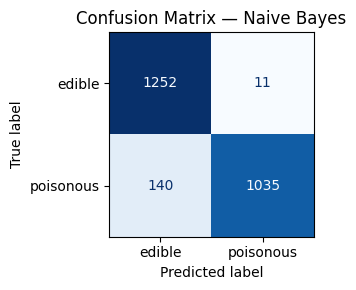

In [10]:
#Naive Bayes

from sklearn.metrics import confusion_matrix, classification_report, precision_score, accuracy_score,recall_score,f1_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
def evaluate_clf(name, y_true, y_pred, show_matrix=False):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─'*45}  {name}")
    print(f"  Accuracy:  {acc:.4f}  |  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}  |  F1 Score:  {f1:.4f}")
    if show_matrix:
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, display_labels=['edible','poisonous'], cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout()
        plt.show()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

print("Setup complete.")
from sklearn.naive_bayes import BernoulliNB

clf_nb = BernoulliNB()
clf_nb.fit(X_train, y_train)

y_pred_nb = clf_nb.predict(X_test)

results = [evaluate_clf("Naive Bayes", y_test, y_pred_nb, show_matrix=True)]


In [ ]:
#SVM

